# Bank Marketing Classification
The aim of the analysis is to explore, prepare, and model the Bank Marketing dataset in order to predict whether a client will subscribe to a term deposit (y). This notebook implements a supervised classification workflow for the UCI Bank Marketing dataset.

The notebook follows an analytics workflow: data examination, data cleaning and preprocessing, model development, and model evaluation. Multiple classification models will be compared using appropriate performance metrics, with particular attention given to class imbalance and the suitability of variables used for prediction.

Dataset: https://archive.ics.uci.edu/dataset/222/bank%2Bmarketing

## References
[1] https://docs.1010data.com/Tutorials/MachineLearningExamples/BankMarketingDataSet.html
https://rstudio-pubs-static.s3.amazonaws.com/1346881_08b338774fe240ec8bb67153fbf45ccc.html

[2]https://www.geeksforgeeks.org/machine-learning/using-columntransformer-in-scikit-learn-for-data-preprocessing/

## Libraries and Tools
1. [Matplotlib ](https://matplotlib.org) - For plotting graphs.
0. [Numpy](https://numpy.org) - Calculations
0. [Pandas](https://pandas.pydata.org) - Dataframes and data manipulation
0. [Imbalanced-learn](https://imbalanced-learn.org/stable/) - Pipeline, SMOTE
0. [Scikit-learn](https://scikit-learn.org/stable/) - Data Analysis functions
0. [Jupyter](https://jupyter.org) - Notebook Tool

### Libraries

In [57]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

### Utilities

In [ ]:
def build_pipeline(
    numeric_transformer: Pipeline,
    bool_transformer: str,
    categorical_transformer: Pipeline,
    numeric_cols: list,
    bool_cols: list,
    categorical_cols: list,
    model: Pipeline,
) -> Pipeline:
    """Create a preprocessing-and-model pipeline.

    Args:
        numeric_transformer (Pipeline): Numeric preprocessing steps.
        bool_transformer (str): Boolean preprocessing steps.
        categorical_transformer (Pipeline): Categorical preprocessing steps.
        numeric_cols (list): Numeric column names.
        bool_cols (list): Boolean column names.
        categorical_cols (list): Categorical column names.
        model (Pipeline): Estimator to attach after preprocessing.

    Returns:
        Pipeline: Combined preprocessing and model pipeline.

    """
    # Combine all preprocessors into a ColumnTransformer
    preprocessor = ColumnTransformer(
        transformers=[
            ('number', numeric_transformer, numeric_cols),
            ('bool', bool_transformer, bool_cols),
            ('category', categorical_transformer, categorical_cols),
        ]
    )
    # Create a full pipeline with preprocessing and the model
    return Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])


def report_grid_search_results(
    grid_search: GridSearchCV, x_test: list, y_test: list
) -> tuple:
    """Accept fitted grid and return the metric report.

    Args:
        grid_search (GridSearchCV): The grid with models.
        x_test (list): Test data x.
        y_test (list): Test data y.

    Returns:
        tuple: The best model, predictions, and probabilities.

    """
    print('=' * 60)
    print('Best Params:', grid_search.best_params_)
    print('Best Recall (CV):', grid_search.best_score_)
    # Evaluate the best model on the test set
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(x_test)
    y_prob = best_model.predict_proba(x_test)[:, 1]

    print('ROC-AUC  :', roc_auc_score(y_test, y_prob))
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
    print('Classification Report:')
    print(classification_report(y_test, y_pred, digits=3))

    return best_model, y_pred, y_prob

## Data Exploration
Examine the different aspects of the dataset in order to develop a general insight into the data.

### Data Overview

- Each row represents a contact record from the bank marketing campaign
- The same client may appear in multiple rows because more than one contact was sometimes required.
- There are 41188 rows and 21 columns

In [4]:
# Importing dataset
dataset = pd.read_csv('dataset/bank-additional-full.csv', sep=';')
dataset

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [5]:
# View first 5 rows of the dataset
dataset.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
# View the number of rows and columns in the dataset.
dataset.shape


(41188, 21)

### Data Quality Checks
#### Types
- The dataset contains varied types, `int`, `str`, and `float`, which will have to be managed before modeling.
- There are a 11 categorical columns, including the target: `'job', 'marital','education','default','housing','loan','contact','month','day_of_week','poutcome','y'`.
- Numerical values show some outliers, for example, `pdays` has `999` for the all greater quartiles.
#### Duplicates
- There are a 12 duplicate rows. In this case, they can be confirmed as duplicates as many of the column values are specific and  they match across all columns.
- Additionally, as the number is small, their removal has nearly no impact on the proportion of the target value with only one of them being positive.
#### Missing Values
- The dataset reports no missing values, however this is incorrect as, upon examination, there are placeholder values such as `unknown` or `999` in use.
- `nonexistent` must also be encoded appropriately for modelling.
- No negative, invalid, numeric values exist.

In [7]:
# View the count and data type of each column in the dataset.
dataset.info()


<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [8]:
# View the statistical summary of the dataset.
dataset.nunique().sort_values()

y                    2
contact              2
default              3
housing              3
loan                 3
poutcome             3
marital              4
day_of_week          5
education            8
previous             8
emp.var.rate        10
month               10
nr.employed         11
job                 12
cons.price.idx      26
cons.conf.idx       26
pdays               27
campaign            42
age                 78
euribor3m          316
duration          1544
dtype: int64

In [9]:
# View the statistical summary of the dataset.
dataset.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [10]:
# Explore catgorical features in the dataset.
original_categorical_columns = dataset.select_dtypes(exclude=['number']).columns.tolist()
original_categorical_columns


['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome',
 'y']

In [11]:
# Check for duplicates
duplicates = dataset.duplicated().sum()
duplicates

np.int64(12)

In [12]:
# Examine duplicates.
dataset[dataset.duplicated(keep=False)]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16819,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no


In [13]:
# Examine proportion of dataset with duplicates against without duplicates.
(dataset['y'] == 'yes').mean(), (dataset.drop_duplicates()['y'] == 'yes').mean()

(np.float64(0.11265417111780131), np.float64(0.11266271614532737))

In [14]:
# Check for missing values in the dataset.
dataset.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [15]:
# Check for 'unknown' values in the dataset.
unknown_summary = (dataset.select_dtypes(include=['object', 'str']) == 'unknown').sum()
unknown_summary

job             330
marital          80
education      1731
default        8597
housing         990
loan            990
contact           0
month             0
day_of_week       0
poutcome          0
y                 0
dtype: int64

In [16]:
# Check for 'nonexistent' values in the 'poutcome' column.
nonexistent_count = (dataset['poutcome'] == 'nonexistent').sum()
nonexistent_count

np.int64(35563)

In [17]:
# Check for 999 values in the 'pdays' column.
pdays_summary = dataset['pdays'].eq(999).sum()
pdays_summary

np.int64(39673)

In [18]:
# Check for negative or zero values in numeric columns.
numeric_validity = pd.Series(
    {
        'age <= 0': (dataset['age'] <= 0).sum(),
        'duration < 0': (dataset['duration'] < 0).sum(),
        'campaign <= 0': (dataset['campaign'] <= 0).sum(),
        'pdays < 0': (dataset['pdays'] < 0).sum(),
        'previous < 0': (dataset['previous'] < 0).sum(),
    }
)
numeric_validity

age <= 0         0
duration < 0     0
campaign <= 0    0
pdays < 0        0
previous < 0     0
dtype: int64

### Target Overview
- The target value is a minority value in an imbalanced dataset.
- There are 36548 no values to 4640 y values, or ~89% to ~11% respectively.

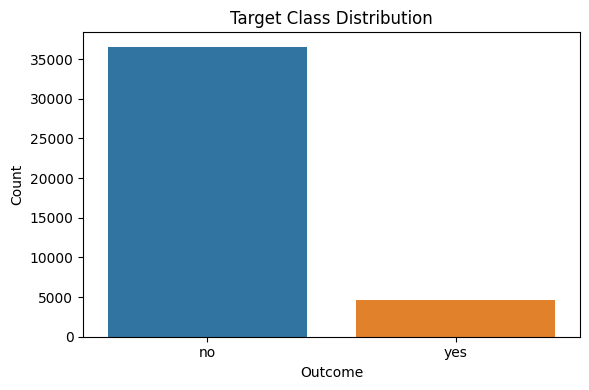

In [19]:
# Check for dataset balance. Target value is imbalanced.
print(dataset['y'].value_counts(normalize=True))
print(dataset['y'].value_counts())

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64
y
no     36548
yes     4640
Name: count, dtype: int64


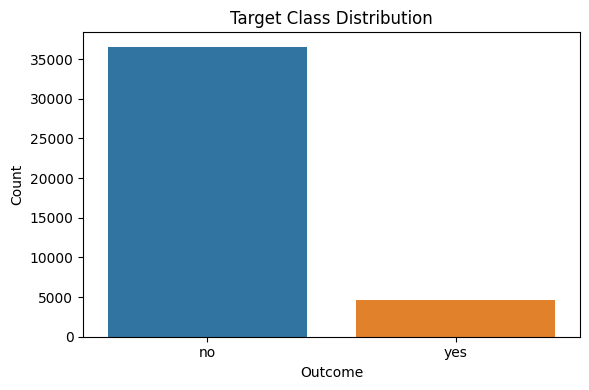

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=dataset, x='y', hue='y', dodge=False, ax=ax)
ax.set_title('Target Class Distribution')
ax.set_xlabel('Outcome')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## Data Cleaning and Preprocessing
Prepare the data for training. There are only a few cleaning steps for now, but other values which must be correctly encoded later. These are general processes. Specific classifiers and pipelines will have further processing applied within their respective headings.

### Cleaning
- Duplicates are removed.
- The `999` placeholder value in pdays is separated into two values: a new `previously_contacted` column with either `False` or `True`; and `NaN` in its own column to more accurately reflect that there is no value.
- The `unknown` value is present across numerous features. This is recognised and will be handled as its own category in preprocessing as it is not the representation of a missing value, but a category in itself.
- Likewise, the `nonexistent` value in the `poutcome` column will be encoded correctly in preprocessing.

In [21]:
# Create a copy, confirm the rows.
df_to_clean = dataset.copy()
df_to_clean.shape

(41188, 21)

In [22]:
# Drop duplicates, confirm the number of rows after dropping duplicates.
df_to_clean = df_to_clean.drop_duplicates().reset_index(drop=True)
df_to_clean.shape

(41176, 21)

In [23]:
# Handle all 999 values in the 'pdays' column by creating a new column.
df_to_clean['previously_contacted'] = np.where(df_to_clean['pdays'] == 999, False, True)
df_to_clean['previously_contacted'].value_counts()

previously_contacted
False    39661
True      1515
Name: count, dtype: int64

In [24]:
# Replace 999 values in 'pdays' column with NaN to indicate missing values.
df_to_clean['pdays'] = df_to_clean['pdays'].replace(999, np.nan).astype('Int64')

In [25]:
df_to_clean.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,previously_contacted
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,<NA>,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,<NA>,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,<NA>,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,<NA>,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,<NA>,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False


### Shared Preprocessing
- The target feature, `y` is encoded as binary.
- `contact` is encoded as a bool, as it only has two values. Bool is currently the type that is created by One-Hot Encoding.
- Categorical columns are identified and encoded as `category` type.

In [26]:
# Change target variable to binary numeric values.
df_to_clean['y'] = df_to_clean['y'].map({'no': 0, 'yes': 1})
df_to_clean.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,previously_contacted
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,<NA>,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,False
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,<NA>,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,False
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,<NA>,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,False
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,<NA>,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,False
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,<NA>,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,False


In [27]:
# Change cellular to boolean values in a new column, then drop the original column.
df_to_clean = df_to_clean.assign(
    contact_cellular=df_to_clean['contact'].eq('cellular')
).drop(columns='contact')
df_to_clean.head()

,age,job,marital,education,default,housing,loan,month,day_of_week,duration,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,previously_contacted,contact_cellular
0,56,housemaid,married,basic.4y,no,no,no,may,mon,261,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,False,False
1,57,services,married,high.school,unknown,no,no,may,mon,149,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,False,False
2,37,services,married,high.school,no,yes,no,may,mon,226,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,False,False
3,40,admin.,married,basic.6y,no,no,no,may,mon,151,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,False,False
4,56,services,married,high.school,no,no,yes,may,mon,307,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,False,False


In [28]:
# Encode category types for SMOTENC.
clean_categorical_columns = df_to_clean.select_dtypes(
    exclude=['number', 'bool']
).columns.tolist()
clean_categorical_columns


['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'month',
 'day_of_week',
 'poutcome']

In [29]:
# Convert categorical columns to 'category' dtype for memory efficiency and compatibility.
for col in clean_categorical_columns:
    df_to_clean[col] = df_to_clean[col].astype('category')
df_to_clean.dtypes

age                        int64
job                     category
marital                 category
education               category
default                 category
housing                 category
loan                    category
month                   category
day_of_week             category
duration                   int64
campaign                   int64
pdays                      Int64
previous                   int64
poutcome                category
emp.var.rate             float64
cons.price.idx           float64
cons.conf.idx            float64
euribor3m                float64
nr.employed              float64
y                          int64
previously_contacted        bool
contact_cellular            bool
dtype: object

### Duration Influence
The `duration` column is highly correlated with positive target, `y`, outcome, with longer calls showing a much higher proportion of successful outcomes. Call duration is only known after the marketing call has taken place, at the same time the outcome is also known. The goal of the model is to predict outcomes before contacting a customer, so this information would not be available in a real-world prediction scenario.[[1](#References)] Including it would produce unrealistically optimistic model performance. Despite its strong apparent predictive power, duration will be excluded from the modelling stage, except for demonstrative use.

- Plot 1 shows high correlation with target feature.
- Plot 2 shows positive outcomes have statistically longer calls.
- Plot 3 shows the distribution of calls with the target outcome tend to be much longer.

| Correlation Heatmap (Pearson) | Duration by y Boxplot | Duration Distribution by y |
|------|------|------|
| 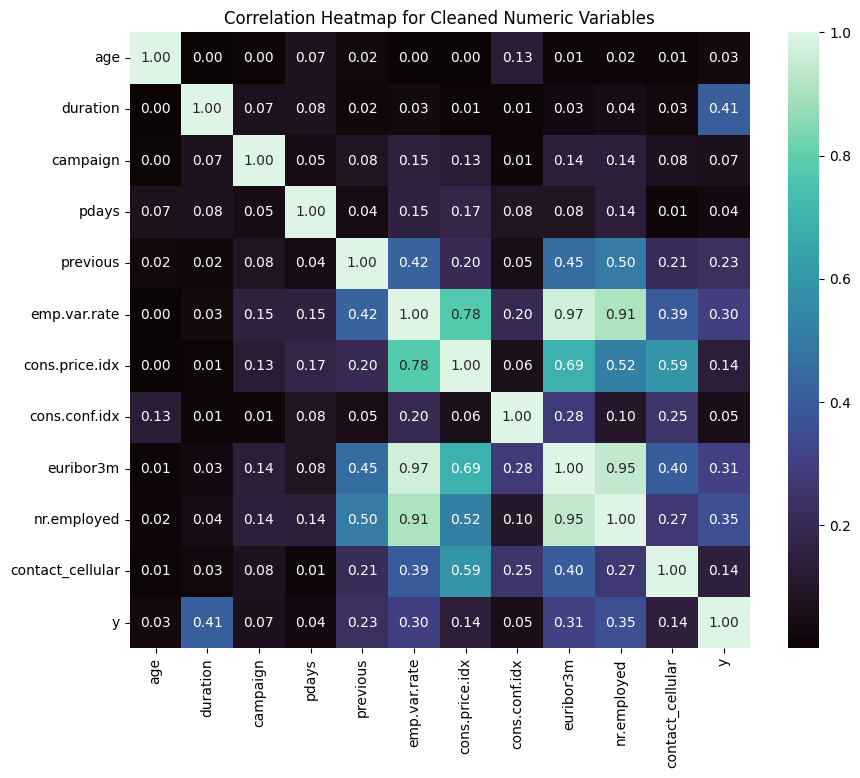 | 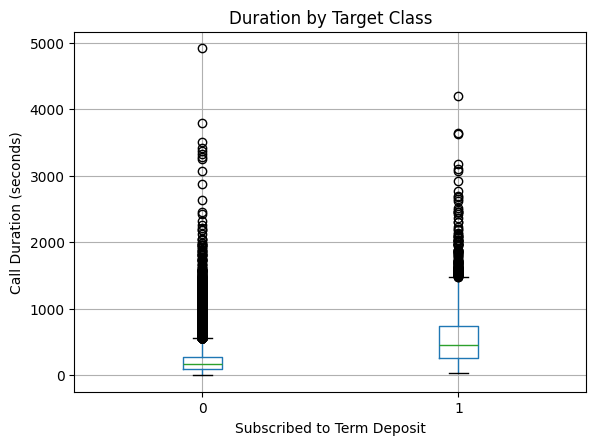 | 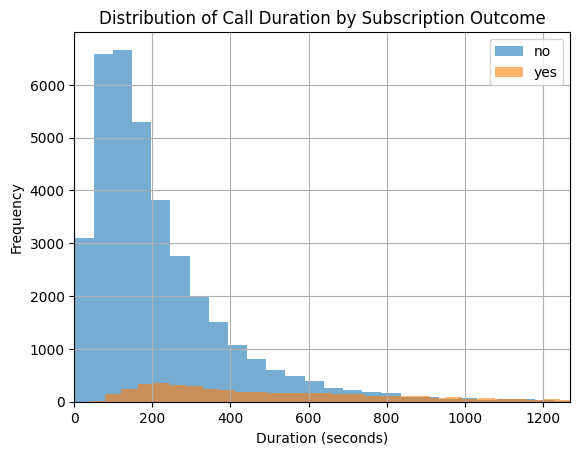 |

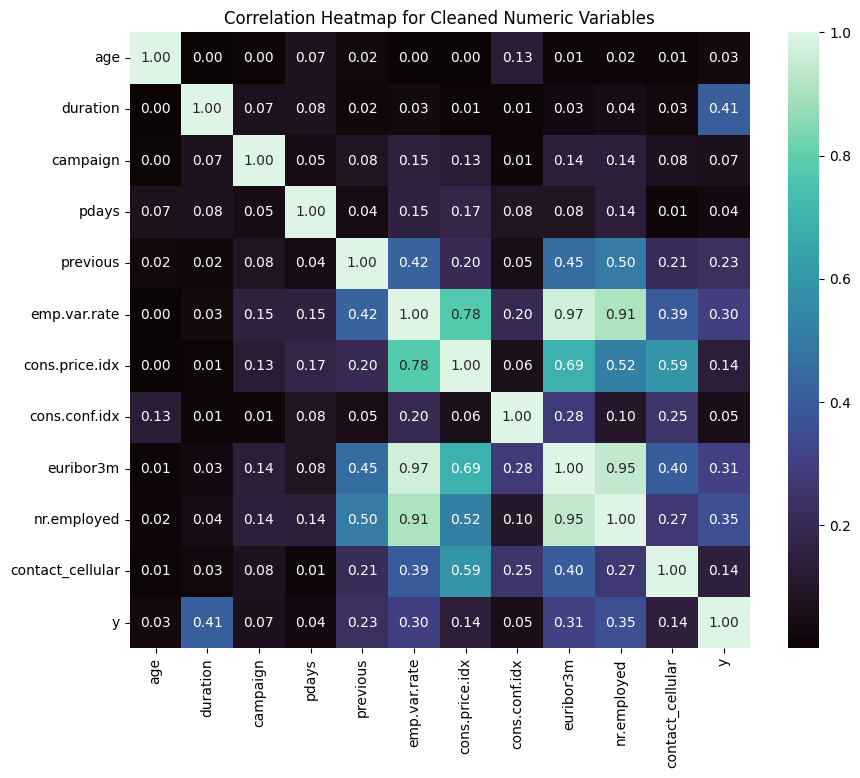

In [30]:
# correlation heatmap for numeric variables.
corr_df = df_to_clean[
    [
        'age',
        'duration',
        'campaign',
        'pdays',
        'previous',
        'emp.var.rate',
        'cons.price.idx',
        'cons.conf.idx',
        'euribor3m',
        'nr.employed',
        'contact_cellular',
        'y',
    ]
].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(np.abs(corr_df), annot=True, fmt='.2f', cmap='mako')
plt.title('Correlation Heatmap for Cleaned Numeric Variables')
plt.show()


In [31]:
# The mean is noticeably lower for the 'no' class
# suggesting the influence of call duration on subscription outcome.
df_to_clean.groupby('y')['duration'].describe()

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
0,36537.0,220.868079,207.116178,0.0,95.0,164.0,279.0,4918.0
1,4639.0,553.256090,401.190736,37.0,253.5,449.0,741.5,4199.0


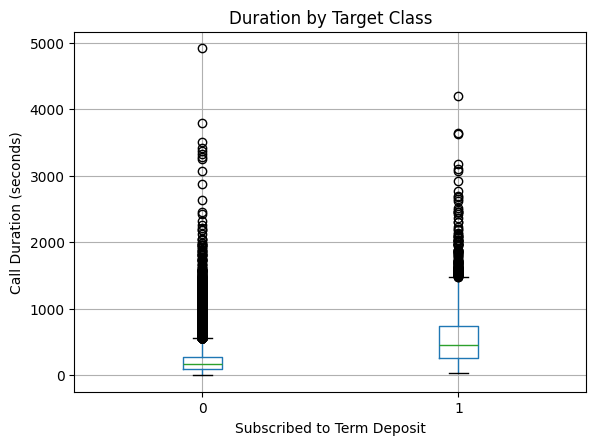

In [32]:
# Visualize the distribution of call duration by subscription outcome.
# The boxplot shows a much higher median and mean for the yes
df_to_clean.boxplot(column='duration', by='y')
plt.title('Duration by Target Class')
plt.suptitle('')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Call Duration (seconds)')
plt.show()

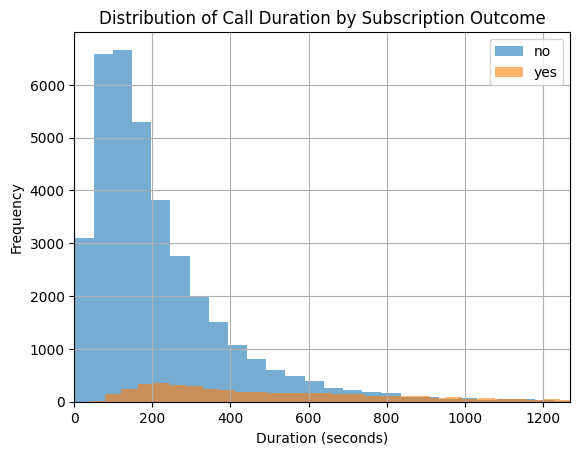

In [33]:
# The histogram shows a right-skewed distribution for both classes.
# The yes class has a longer tail, indicating that longer calls are more likely to result
# in a subscription.

x_max = df_to_clean['duration'].quantile(0.99)

df_to_clean[df_to_clean['y'] == 0]['duration'].hist(alpha=0.6, bins=100, label='no')
df_to_clean[df_to_clean['y'] == 1]['duration'].hist(alpha=0.6, bins=100, label='yes')

plt.xlim(0, x_max)
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.title('Distribution of Call Duration by Subscription Outcome')
plt.legend()
plt.show()

### Shared Train / Test Split
- The dataset is finalised after cleaning and preprocessing.
- The train/test split is done here to ensure consistency across models.
- The train/test split is stratified due to the imbalance in the target variable.

In [34]:
general_df = df_to_clean.drop(columns='duration').copy()
general_df.head()

,age,job,marital,education,default,housing,loan,month,day_of_week,campaign,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,previously_contacted,contact_cellular
0,56,housemaid,married,basic.4y,no,no,no,may,mon,1,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,False,False
1,57,services,married,high.school,unknown,no,no,may,mon,1,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,False,False
2,37,services,married,high.school,no,yes,no,may,mon,1,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,False,False
3,40,admin.,married,basic.6y,no,no,no,may,mon,1,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,False,False
4,56,services,married,high.school,no,no,yes,may,mon,1,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,False,False


In [35]:
# Prepare features and target variable for modeling.
x = general_df.drop(columns='y')
y = general_df['y']

# Verify shapes
print(f'Shape of X: {x.shape}')
print(f'Shape of y: {y.shape}')

Shape of X: (41176, 20)
Shape of y: (41176,)


In [36]:
# Split the set into training and testing
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=37
)
# Ensure they produce similar values
print('Train positive rate:', y_train.mean())
print('Test positive rate:', y_test.mean())
print(x_train.shape, x_test.shape)

Train positive rate: 0.11265938069216758
Test positive rate: 0.11267605633802817
(32940, 20) (8236, 20)


## Model 1: Logistic Regression
Logistic Regression is the first main classifier in this notebook. It is a standard method for binary outcomes and provides a clear baseline before moving on to more complex models. It is useful for this dataset because the target is binary, the predictors include a mixture of numeric and categorical variables, and the model produces probabilities that help assess how strongly each case is associated with the positive class. 

The model is trained using the cleaned dataset with `duration` removed from the main modelling set. Numerical features are imputed and scaled, categorical features are one-hot encoded, and class imbalance is examined both with and without SMOTENC. The baseline Logistic Regression model provides a performance benchmark for comparison.

### Logistic Regression Preprocessing
- Data types are separated into respective lists and preprocesssed.
- Numerical data types, namely `pdays` and it's `NaN` value is imputed with the median and scaled. The median was chosen as the feature is heavily skewed, so the mean would also be quite skewed. Othr features do not need imputation as they have no missing values.
- Booleans are left as sklearn will process them as binary indicators.
- Categorical features are one-hot encoded.
- `ColumnTransformer`[[2](#references)] is used to create a preprocessor pipeline.
- `LogisticRegression` pipeline is created using the preprocessing.

In [37]:
# Identify column groups
numeric_cols = x.select_dtypes(include=['number']).columns.tolist()
bool_cols = x.select_dtypes(include=['bool']).columns.tolist()
categorical_cols = x.select_dtypes(include=['category']).columns.tolist()

print('Numeric:', numeric_cols)
print('Boolean:', bool_cols)
print('Categorical:', categorical_cols)

Numeric: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Boolean: ['previously_contacted', 'contact_cellular']
Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'month', 'day_of_week', 'poutcome']


In [ ]:
# Create preprocessing pipeline for use in modeling.
# Numeric preprocessing - replacing missing values in pdays with median as it is skewed.
numeric_transformer = Pipeline(
    steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]
)

# Boolean features can pass through unchanged
bool_transformer = 'passthrough'

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[('encoder', OneHotEncoder(handle_unknown='ignore'))]
)

# Build Pipeline
log_reg_baseline = build_pipeline(
    numeric_transformer,
    bool_transformer,
    categorical_transformer,
    numeric_cols,
    bool_cols,
    categorical_cols,
    LogisticRegression(max_iter=2000, random_state=37),
)

### Base Logistic Regression Development
- Hyperparameters are set to optimise results: `C` to control regularisation, `solver` for different algorithms, and `class-weight` to balance the minority class in the dataset.
- `GridSearchCV` is used to tune the hyperparameters.
- Cross-Validation is used with recall as scoring to identify the best model.
- Final performance is interpreted using precision, recall, f1, and ROC-AUC.
- Accuracy is not a suitable metric as the dataset is imbalanced.

In [ ]:
# Choose hyperparameters.
log_reg_params = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['lbfgs', 'liblinear'],
    'model__class_weight': [None, 'balanced'],
}

# Grid search (recall as scoring, same as your best model)
gs_log_reg = GridSearchCV(
    log_reg_baseline, param_grid=log_reg_params, scoring='recall', cv=5, n_jobs=-1
)
gs_log_reg.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=37))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__solver': ['lbfgs', 'liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter cand

### Base Logistic Regression Results
- The baseline model provides the first comparison point for later classifiers.
- CV Recall is `0.639`, an acceptable result.
- Recall is acceptable at `0.621`.
- Precision is very low at `0.327`, demonstrating many false positives.
- ROC-AUC is `0.782` which is acceptable. It is not random but not well-performing either.
- F1 is low at `0.428`, showing that the ratio of precision to recall is not great.

In [ ]:
# Report results
best_model_log_reg, y_pred_log_reg, y_prob_log_reg = report_grid_search_results(
    gs_log_reg, x_test, y_test
)

Best Params: {'model__C': 0.01, 'model__class_weight': 'balanced', 'model__solver': 'lbfgs'}
Best Recall (CV): 0.6391825955095719
ROC-AUC  : 0.782353832833173
Confusion Matrix:
[[6120 1188]
 [ 352  576]]
Classification Report:
              precision    recall  f1-score   support

           0      0.946     0.837     0.888      7308
           1      0.327     0.621     0.428       928

    accuracy                          0.813      8236
   macro avg      0.636     0.729     0.658      8236
weighted avg      0.876     0.813     0.836      8236



### Logistic Regression SMOTENC Preparation
- `SMOTENC` is used because the dataset contains both numerical and categorical predictors.
- Imbalanced Pipeline is used in coordination with `SMOTENC`.
- Resampling is applied only to the training data after the train/test split to maintain comparability.
- Numerical values are imputed and are not scaled as `SMOTENC` does not require it.
- Categorical columns are preserved so that `SMOTENC` can identify them correctly.
- The aim is to improve minority-class detection without altering the test set.
- Training data is resampled to address imbalance.
- Class imbalance is reported both before and after `SMOTENC`

In [41]:
# Create safe copies for SMOTENC
x_train_smote = x_train.copy()
x_test_smote = x_test.copy()

# Impute numeric columns before SMOTENC
smote_imputer = SimpleImputer(strategy='median')

x_train_smote[numeric_cols] = smote_imputer.fit_transform(x_train_smote[numeric_cols])
x_test_smote[numeric_cols] = smote_imputer.transform(x_test_smote[numeric_cols])

# Get categorical indices for SMOTENC
categorical_indices = x_train_smote.columns.get_indexer(categorical_cols).tolist()
categorical_indices

[1, 2, 3, 4, 5, 6, 7, 8, 12]

In [42]:
# Show class distribution before and after SMOTENC.
# This cell is for example purposes only.
smotenc_report = SMOTENC(categorical_features=categorical_indices, random_state=37)

x_train_balanced, y_train_balanced = smotenc_report.fit_resample(x_train_smote, y_train)

print('Training class distribution before SMOTENC:')
print(y_train.value_counts())
print(y_train.value_counts(normalize=True).round(3))

print('Training class distribution after SMOTENC:')
print(y_train_balanced.value_counts())
print(y_train_balanced.value_counts(normalize=True).round(3))

Training class distribution before SMOTENC:
y
0    29229
1     3711
Name: count, dtype: int64
y
0    0.887
1    0.113
Name: proportion, dtype: float64
Training class distribution after SMOTENC:
y
0    29229
1    29229
Name: count, dtype: int64
y
0    0.5
1    0.5
Name: proportion, dtype: float64


In [43]:
# Create a pipeline using ImbPipeline to include SMOTENC in the modeling process.
log_reg_smotenc_pipe = ImbPipeline(
    steps=[
        ('smote', SMOTENC(categorical_features=categorical_indices, random_state=37)),
        (
            'preprocessor',
            ColumnTransformer(
                transformers=[
                    ('number', numeric_transformer, numeric_cols),
                    ('bool', bool_transformer, bool_cols),
                    ('category', categorical_transformer, categorical_cols),
                ]
            ),
        ),
        ('model', LogisticRegression(max_iter=2000, random_state=37)),
    ]
)

### Logistic Regression SMOTENC Model Development
- Hyperparameters remain the same but class weighting is removed.
- The balanced training data is preprocessed using the same encoding and scaling structure as the baseline model.
- GridSearchCV is again used to tune the classifier.
- Recall remains the primary scoring metric.
- The model is evaluated on the original test set for fair comparison.

In [ ]:
# Select Hyperparameters for the GridSearchCV
log_reg_params_smotenc = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['lbfgs', 'liblinear'],
    'model__class_weight': [None],
}

log_reg_smotenc = LogisticRegression(max_iter=2000, random_state=37)
# Grid search (recall as scoring, same as your best model)
gs_log_smotenc = GridSearchCV(
    estimator=log_reg_smotenc_pipe,
    param_grid=log_reg_params_smotenc,
    scoring='recall',
    cv=5,
    n_jobs=-1,
)

gs_log_smotenc.fit(x_train_smote, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=37))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None], 'model__solver': ['lbfgs', 'liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is dis

### Logistic Regression SMOTENC Results
- The baseline model provides better performance overall.
- CV Recall is `0.607`, a lower result.
- Recall is lower at `0.605`.
- Precision is lower at `0.297`, demonstrating more false positives.
- F1 score is also lower at `0.398`.
- ROC-AUC is `0.762` which is worse.

In [ ]:
# Report results
best_model_log_smotenc, y_pred_log_smotenc, y_prob_log_smotenc = (
    report_grid_search_results(gs_log_smotenc, x_test_smote, y_test)
)

Best Params: {'model__C': 0.01, 'model__class_weight': None, 'model__solver': 'liblinear'}
Best Recall (CV): 0.6076483840190384
ROC-AUC  : 0.7621299225695034
Confusion Matrix:
[[5979 1329]
 [ 367  561]]
Classification Report:
              precision    recall  f1-score   support

           0      0.942     0.818     0.876      7308
           1      0.297     0.605     0.398       928

    accuracy                          0.794      8236
   macro avg      0.619     0.711     0.637      8236
weighted avg      0.869     0.794     0.822      8236



## Model 2: Naive Bayes
Gaussian Naive Bayes is the second probabilistic model that provides a useful comparison with Logistic Regression because it approaches probability with a different algorithm. It is suitable because binary target variables can be modelled probabilistically, and the mixed predictor types can be transformed into numeric form through preprocessing. The same train/test split is retained from the previous model so that results remain directly comparable.

This model is fitted using the cleaned modelling dataset with `duration` excluded from the main analysis. The base Naive Bayes model therefore acts as an additional probabilistic reference point before the notebook moves on to the remaining classification models.

### Naive Bayes Preprocessing
- The same numerical, boolean, and categorical column groups are retained for consistency.
- Numerical variables are imputed using the median and scaled using `StandardScaler`, matching the earlier modelling structure.
- Booleans are left as sklearn will process them as binary indicators.
- Categorical features are one-hot encoded.
- `OneHotEncoder` uses `sparse_output=False` because Gaussian Naive Bayes does not support sparse matrices, differently from Logistic Regression.
- This preprocessing ensures that all predictors are converted into a dense numeric format suitable for `GaussianNB`.

In [ ]:
# Change the categorical preprocessor for sparse output=False as
# Naive Bayes does not support sparse matrices.
nb_categorical_transformer = Pipeline(
    steps=[('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]
)

# Build Naive Bayes pipeline
nb_base = build_pipeline(
    numeric_transformer,
    bool_transformer,
    nb_categorical_transformer,
    numeric_cols,
    bool_cols,
    categorical_cols,
    GaussianNB(),
)

### Naive Bayes Model Development
- Same train/test split as the previous model.
- `GridSearchCV` is used to tune the model so that the notebook remains consistent in structure across model sections.
- The hyperparameter tuned is `var_smoothing`, which controls the stability added to the variance.
- Recall remains the primary scoring metric during cross-validation because the target class is imbalanced.
- The fitted model is then evaluated on the untouched test set for fair comparison with Logistic Regression.

In [47]:
# Tune hyperparameters for Gaussian Naive Bayes using GridSearchCV.
# Recall increases with bigger numbers, but precision decreases.
nb_params = {'model__var_smoothing': [1e-13, 1e-12, 1e-11, 1e-10]}

gs_nb = GridSearchCV(nb_base, param_grid=nb_params, scoring='recall', cv=5, n_jobs=-1)

# Fit the model on the original training data.
gs_nb.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...aussianNB())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__var_smoothing': [1e-13, 1e-12, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold

### Naive Bayes Results
- With higher numbers for `var_smoothing`, recall improves but at the cost of precision. Lower numbers worsen recall but improve f1.
- CV Recall is `0.682`, higher than both baseline Logistic Regression and Logistic Regression with `SMOTENC`.
- ROC-AUC is `0.757`, slightly lower than baseline Logistic Regression.
- Recall is `0.669`.
- Precision is `0.260`, lower than Logistic Regression and indicates a high number of false positives.
- F1 is `0.375`, showing that overall balance between precision and recall remains weak.
- Overall, Gaussian Naive Bayes can achieve higher recall but with an inverse cost to precision, th model is not viable.

In [ ]:
# Report results
best_model_nb, y_pred_nb, y_prob_nb = report_grid_search_results(gs_nb, x_test, y_test)

Best Params: {'model__var_smoothing': 1e-13}
Best Recall (CV): 0.6817553228152786
ROC-AUC  : 0.7574524936064397
Confusion Matrix:
[[5544 1764]
 [ 307  621]]
Classification Report:
              precision    recall  f1-score   support

           0      0.948     0.759     0.843      7308
           1      0.260     0.669     0.375       928

    accuracy                          0.749      8236
   macro avg      0.604     0.714     0.609      8236
weighted avg      0.870     0.749     0.790      8236



## Model 3: Decision Tree
Decision Tree is the first main classifier model. It is useful because it can model non-linear relationships and interactions between variables without requiring feature scaling. This makes it a strong contrast to the previous probabilistic models.

The model is trained using the cleaned dataset with `duration` removed from the main modelling set. Numerical features are imputed where needed, but not scaled, categorical features are one-hot encoded The same stratified train/test split is retained so that results remain directly comparable with the previous models.

### Decision Tree Preprocessing
- Numerical variables are imputed using the median. This is mainly required for `pdays`, where `999` was replaced with `NaN` during cleaning.
- Numerical variables are not scaled as standardisation is not necessary for decision trees.
- Booleans are left as sklearn will process them as binary indicators.
- Categorical features are one-hot encoded.

In [49]:
# Numeric preprocessing
# Remove scaling as decision trees are not affected by feature scaling.
dt_numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

# Boolean and categorical transformers can remain the same.
dt_pipeline = build_pipeline(
    dt_numeric_transformer,
    bool_transformer,
    categorical_transformer,
    numeric_cols,
    bool_cols,
    categorical_cols,
    DecisionTreeClassifier(random_state=37)
)

### Decision Tree Model Development
- Same train/test split as the previous model for comparability.
- `GridSearchCV` is used to tune the main hyperparameters that control tree growth and split quality.
- The hyperparameters that are used: `criterion` for split quality; `max_depth`, `min_samples_split`, and `min_samples_leaf` control tree growth and help reduce overfitting; `class_weight` to balance the minority class.
- The parameter grid used is:.
- Recall is used to remain consistent with the previous models.

In [ ]:
# Select Hyperparameters for the GridSearchCV
dt_params = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [3, 5, 7, None],
    'model__min_samples_split': [2, 5, 7, 10],
    'model__min_samples_leaf': [1, 5, 10],
    'model__class_weight': [None, 'balanced'], 
}

gs_dt = GridSearchCV(dt_pipeline, param_grid=dt_params, scoring='recall', cv=5, n_jobs=-1)

gs_dt.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=37))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': [None, 'balanced'], 'model__criterion': ['gini', 'entropy'], 'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the c

### Decision Tree Results
- CV Recall is `0.645`, comparable to previous models.
- Recall is `0.650`
- Precision is `0.319`
- F1 is `0.428` for the positive class.
- The ROC-AUC score is `0.786`.
- The scores are slightly better than the baseline Logistic Regression model on recall and ROC-AUC, though precision remains slightly lower.
- Overall, the Decision Tree performs competitively with earlier models.

In [ ]:
# Report results
best_model_dt, y_pred_dt, y_prob_dt = report_grid_search_results(gs_dt, x_test, y_test)

Best Params: {'model__class_weight': 'balanced', 'model__criterion': 'entropy', 'model__max_depth': 7, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}
Best Recall (CV): 0.6445614595161308
ROC-AUC  : 0.7857004251363645
Confusion Matrix:
[[6018 1290]
 [ 325  603]]
Classification Report:
              precision    recall  f1-score   support

           0      0.949     0.823     0.882      7308
           1      0.319     0.650     0.428       928

    accuracy                          0.804      8236
   macro avg      0.634     0.737     0.655      8236
weighted avg      0.878     0.804     0.831      8236



## Model 4: Random Forest
Random Forest is the second classifier model. It is a bagging-type ensemble extension of Decision Tree that combines many trees built on the sample data. This can improve performance compared to a single Decision Tree. It is useful because it can model non-linear relationships and interactions between variables without requiring feature scaling.

The model is trained using the cleaned dataset with `duration` removed from the main modelling set. Numerical features are imputed where needed, but not scaled, categorical features are one-hot encoded The same stratified train/test split is retained so that results remain directly comparable with the previous models.

### Random Forest Preprocessing
- Preprocessing  methods are identical to Decision Tree.


In [52]:
# Random Forest can use the same preprocessing as Decision Tree.
# So we reuse the preprocessors from before.
# Build Random Forest pipeline
rf_pipeline = build_pipeline(
    dt_numeric_transformer,
    bool_transformer,
    categorical_transformer,
    numeric_cols,
    bool_cols,
    categorical_cols,
    RandomForestClassifier(random_state=37, n_jobs=-1)
)

### Random Forest Model Development
- The same train/test split as the previous models.
- `GridSearchCV` is used to tune the main Random Forest hyperparameters.
- The hyperparameters that are used: `n_estimators` for tree number; `max_depth`, `min_samples_split`, and `min_samples_leaf` control tree growth and help reduce overfitting `max_features` controls number of features; `class_weight` to balance the minority class.
- Recall is used as the main scoring metric to remain consistent with the earlier models.

In [ ]:
# Select Hyperparameters for the GridSearchCV
rf_params = {
    'model__n_estimators': [20, 50, 100],
    'model__max_depth': [None, 2, 5],
    'model__min_samples_split': [2, 4],
    'model__min_samples_leaf': [1, 5],
    'model__max_features': ['sqrt', 'log2'],
    'model__class_weight': [None, 'balanced', 'balanced_subsample']
}

gs_rf = GridSearchCV(
    rf_pipeline,
    param_grid=rf_params,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

gs_rf.fit(x_train, y_train)

/Users/Rory/Documents/programming/adv-an-ca1/adv-an-ca1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/Rory/Documents/programming/adv-an-ca1/adv-an-ca1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/Rory/Documents/programming/adv-an-ca1/adv-an-ca1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thr

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=37))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': [None, 'balanced', ...], 'model__max_depth': [None, 2, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1

### Random Forest Results
- CV Recall is `0.707`.
- Recall is `0.686`
- Precision is `0.258`
- F1 is `0.375` for the positive class.
- The ROC-AUC score is `0.775`.
- The model performs similarly to the single Decision Tree.
- Overall, Random Forest provides similar performance as the previous tree-based model.

In [ ]:
# Report results
best_model_rf, y_pred_rf, y_prob_rf = report_grid_search_results(gs_rf, x_test, y_test)

Best Params: {'model__class_weight': 'balanced', 'model__max_depth': 2, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 50}
Best Recall (CV): 0.7073563501939032
ROC-AUC  : 0.7750356688702038
Confusion Matrix:
[[5473 1835]
 [ 291  637]]
Classification Report:
              precision    recall  f1-score   support

           0      0.950     0.749     0.837      7308
           1      0.258     0.686     0.375       928

    accuracy                          0.742      8236
   macro avg      0.604     0.718     0.606      8236
weighted avg      0.872     0.742     0.785      8236



## Model 5: Adaptive Boost
Adaptive Boost is a boosting-type ensemble classifier that builds a sequence of weak learners. It is included here as an additional classifier model to compare against the single Decision Tree and the Random Forest ensemble.

### Adaptive Boost Preprocessing

In [58]:
# Adaptive Boost can use the same preprocessing as Decision Tree and Random Forest.
# Reuse the same numeric, boolean, and categorical preprocessors.
ada_pipeline = build_pipeline(
    dt_numeric_transformer,
    bool_transformer,
    categorical_transformer,
    numeric_cols,
    bool_cols,
    categorical_cols,
    AdaBoostClassifier(
        estimator=DecisionTreeClassifier(random_state=37),
        random_state=37
    )
)

### Adaptive Boost Model Development

In [ ]:
# Select Hyperparameters for the GridSearchCV
ada_params = {
    'model__n_estimators': [50, 100, 150, 200],
    'model__learning_rate': [0.01, 0.1, 0.5, 1.0],
    'model__estimator__max_depth': [1, 2],
    'model__estimator__min_samples_split': [2, 5, 10],
    'model__estimator__min_samples_leaf': [1, 3, 5, 7]
}

gs_ada = GridSearchCV(
    ada_pipeline,
    param_grid=ada_params,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

gs_ada.fit(x_train, y_train)

# Adaptive Boost Results

In [ ]:
# Report results
best_model_ada, y_pred_ada, y_prob_ada = report_grid_search_results(gs_ada, x_test, y_test)

AttributeError: 'GridSearchCV' object has no attribute 'best_params_'